# XGBoost

In [4]:
import pandas as pd

df = pd.read_csv("data/lectures evaluation.csv", header=None)
df.columns = ["c1", "c2", "c3", "c4", "target"]

print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df["target"].value_counts().sort_index())

Shape: (1000, 5)

Class distribution:
target
0.0     93
1.0    280
2.0    403
3.0    197
4.0     27
Name: count, dtype: int64


In [ ]:
print(df.head(10).to_string())
print("\nUnique values for each criterion:")
for col in ["c1", "c2", "c3", "c4"]:
    print(f"  {col}: {sorted(df[col].unique())}")

     c1    c2    c3    c4  target
0  1.00  0.50  0.75  0.00       2
1  0.75  0.75  0.00  0.75       2
2  0.50  1.00  0.25  0.00       1
3  0.50  0.25  0.50  0.75       1
4  0.50  0.75  1.00  0.50       1
5  0.00  0.25  0.25  0.00       0
6  0.25  0.50  0.50  0.25       1
7  1.00  0.50  1.00  0.75       2
8  0.75  0.75  0.75  0.25       1
9  0.00  1.00  1.00  0.25       1

Unique values per criterion:
  c1: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
  c2: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
  c3: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
  c4: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]


### Dataset Description

Lectures evaluation dataset with 1000 alternatives, 4 normalized criteria (c1–c4)
with ordinal values in {0, 0.25, 0.5, 0.75, 1.0}, and a quality class.

Criteria are assumed gain-type — confirmed later via PDP and SHAP analysis.

### Class Merging

Original 5 classes (0–4) are imbalanced — class 0 has 93 and class 4 only 27 samples.
We merge the boundary classes: 0+1 → 0 (low), 2 → 1 (medium), 3+4 → 2 (high).
This gives 3 balanced classes with enough samples each to train and evaluate reliably.

In [5]:
target_map = {0.0: 0, 1.0: 0, 2.0: 1, 3.0: 2, 4.0: 2}
df["target"] = df["target"].map(target_map)
print(df["target"].value_counts().sort_index())

target
0    373
1    403
2    224
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

X = df[["c1", "c2", "c3", "c4"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234, stratify=y
)

print(f"Train: {len(X_train)}  Test: {len(X_test)}")
print("\nTrain class distribution:")
print(y_train.value_counts().sort_index())
print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Train: 800  Test: 200

Train class distribution:
target
0    298
1    323
2    179
Name: count, dtype: int64

Test class distribution:
target
0    75
1    80
2    45
Name: count, dtype: int64


## Model Training

We use XGBoost with a multiclass softmax objective for 3-class output.
Shallow trees (max depth 3) keep the model interpretable and reduce overfitting.

We initially assume all criteria are gain-type and apply increasing monotone
constraints. This assumption is verified later via PDP and SHAP analysis.

The ensemble uses 100 trees, which turned to be enough to capture patterns without memorizing the training set.

In [9]:
import xgboost as xgb

CRITERIA_NR = 4
NUM_CLASSES = 3

model = xgb.XGBClassifier(
    max_depth=3,
    eta=0.1,
    n_estimators=100,
    objective="multi:softprob",
    num_class=NUM_CLASSES,
    monotone_constraints="(1,1,1,1)",
    eval_metric="mlogloss",
    seed=1234,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### Metrics

We report Accuracy, weighted F1, and AUC on both train and test sets.

Weighted F1 accounts for class imbalance by weighting each class by its support.

AUC is computed one-vs-rest, measuring how well the model separates each class
from the remaining two.

In [10]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate(model, X, y, split_name="Test"):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average="weighted")
    auc = roc_auc_score(y, y_proba, multi_class="ovr", average="weighted")

    print(f"[{split_name}]  Accuracy: {acc:.4f}  |  F1: {f1:.4f}  |  AUC: {auc:.4f}")

evaluate(model, X_train, y_train, "Train")
evaluate(model, X_test, y_test, "Test ")

[Train]  Accuracy: 0.7250  |  F1: 0.7260  |  AUC: 0.8729
[Test ]  Accuracy: 0.7250  |  F1: 0.7255  |  AUC: 0.8770


### Confusion Matrix

A confusion matrix shows the distribution of correct and incorrect predictions
across all classes. 

In a multiclass classification problem with ordered classes we expect most errors between neighboring classes.

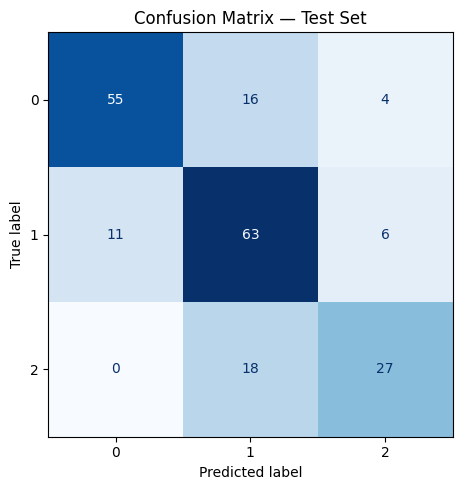

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_test = model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

### Results

The most errors are on the boundary between adjacent classes (0 and 1, 1 and 2),
which was expected, since the criteria values overlap there. No low alternative
was predicted as high, confirming the model respects the natural class ordering.

## Section 2.1 Explanation of Decisions

### SHAP Values

SHAP (SHapley Additive exPlanations) explains each prediction by attributing
a contribution value to each criterion. TreeExplainer is exact for XGBoost —
not an approximation. We use a beeswarm plot for global interpretation across
all test samples.

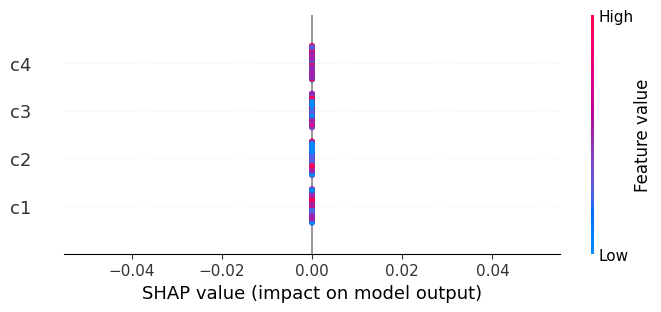

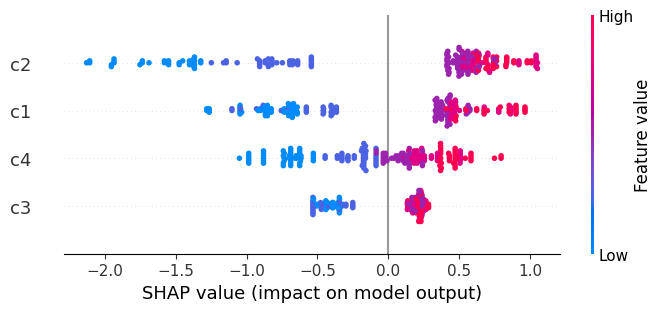

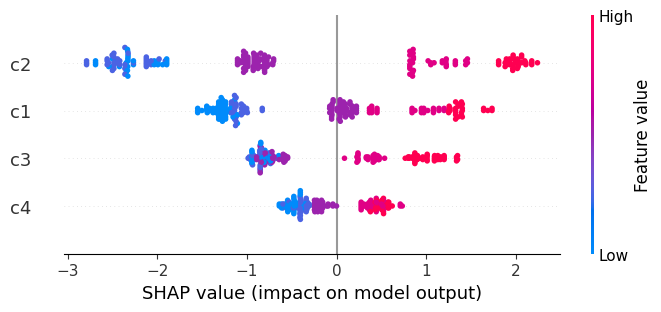

In [16]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
# shape: (n_samples, n_features, n_classes)

shap.plots.beeswarm(shap_values[:, :, 0], show=True)  # class 0
shap.plots.beeswarm(shap_values[:, :, 1], show=True)  # class 1
shap.plots.beeswarm(shap_values[:, :, 2], show=True)  # class 2

## SHAP Interpretation

**Class 0 (low):** SHAP values are near zero for all criteria. The model does not
actively predict class 0, it falls there by default when evidence for classes 1 and 2
is absent. This is expected given class 0 is the merged boundary group.

**Class 1 (medium):** c2 is the dominant criterion — high values (red) push strongly
toward class 1, low values (blue) push away. c1 follows the same pattern but weaker.
c3 and c4 have minimal spread, confirming low importance from the gain plot.

**Class 2 (high):** c2 again dominates, but now high values push even more strongly
positive (up to +2). c1 also contributes significantly. c3 shows some effect,
c4 remains weak. The clear blue/red separation confirms all criteria are monotone,
low feature value always pushes negative, high always pushes positive.

**Summary:** As we could previously seen on the feature importance plot, also Shap shows that c2 is the most influential criterion, approximately 2x more than c1. c3 and c4 have limited effect. 

In [18]:
results = X_test.copy()
results["true"] = y_test.values
results["predicted"] = model.predict(X_test)

# show some examples from each class
for cls in range(3):
    print(f"\n--- Class {cls} samples ---")
    print(results[results["true"] == cls].head(3).to_string())


--- Class 0 samples ---
       c1    c2    c3    c4  true  predicted
922  0.50  0.25  0.50  0.75     0          1
574  0.00  0.00  0.25  1.00     0          0
194  0.25  0.50  0.50  0.25     0          1

--- Class 1 samples ---
       c1    c2    c3    c4  true  predicted
757  1.00  0.25  0.75  0.25     1          1
673  0.25  0.50  0.50  0.75     1          1
786  1.00  0.75  0.50  0.00     1          1

--- Class 2 samples ---
      c1    c2   c3    c4  true  predicted
540  0.5  1.00  1.0  1.00     2          2
515  0.0  1.00  1.0  0.50     2          2
962  0.5  0.75  0.5  0.75     2          1


### Explaining Individual Predictions (SHAP Waterfall)

We select 3 alternatives, two correct predictions, plus one misclassification made by XGBoost.

#### Why was each decision made?

For each of the 3 selected alternatives we explain the model's decision by
decomposing the prediction into per-criterion contributions using SHAP waterfall plots.

Each bar shows how much a criterion pushed the prediction above or below the
average model output: red bars increase the predicted class, blue bars decrease it.




Alternative 574 | true: 0 | predicted: 0
  Showing SHAP for class 2


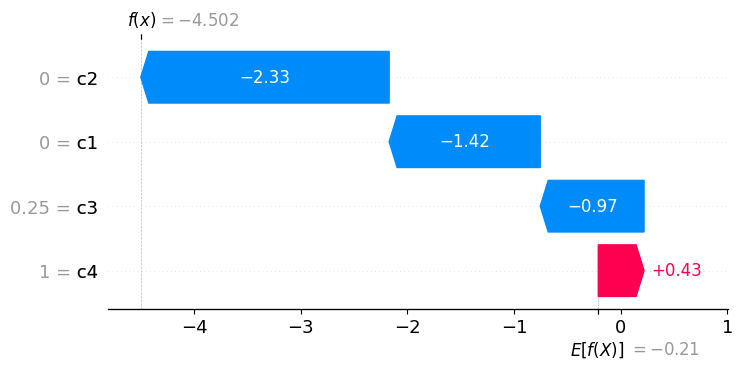


Alternative 757 | true: 1 | predicted: 1
  Showing SHAP for class 2


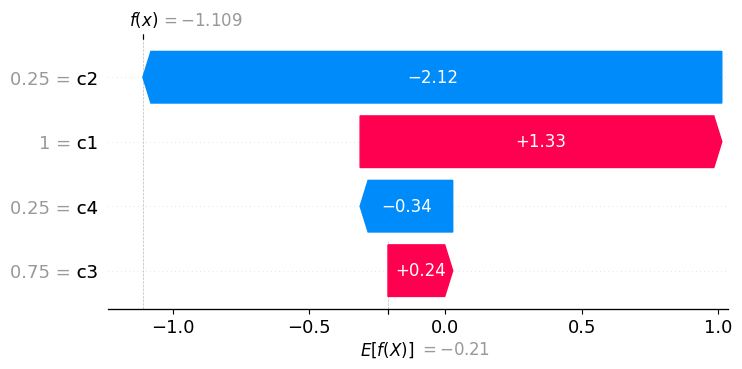


Alternative 962 | true: 2 | predicted: 1
  Showing SHAP for class 2


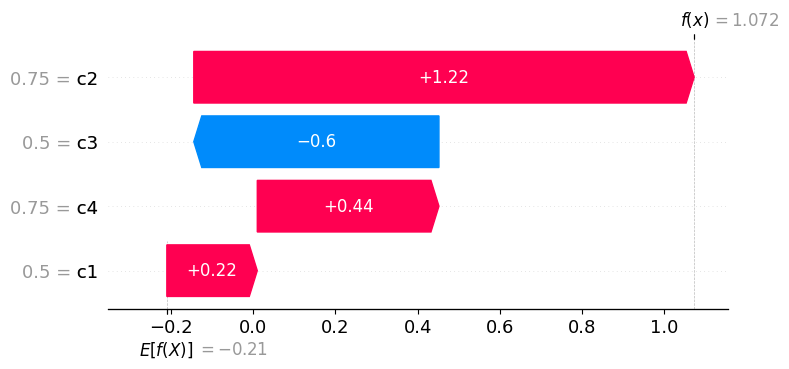

In [23]:
import numpy as np

ALT_INDICES = [574, 757, 962]

for idx in ALT_INDICES:
    row = results.loc[idx]
    true_cls = int(row["true"])
    pred_cls = int(row["predicted"])
    print(f"\nAlternative {idx} | true: {true_cls} | predicted: {pred_cls}")

    pos = X_test.index.get_loc(idx)
    # show waterfall for predicted class only if it has meaningful SHAP values
    # otherwise show the class with highest absolute SHAP sum
    shap_per_class = [shap_values[pos, :, c].values for c in range(3)]
    best_cls = int(np.argmax([np.abs(s).sum() for s in shap_per_class]))
    print(f"  Showing SHAP for class {best_cls}")
    shap.plots.waterfall(shap_values[pos, :, best_cls])

**Alternative 574** (true: 0, predicted: 0) — strongest signal is against class 2.
c2=0 and c1=0 pull heavily negative (−2.33, −1.42), meaning very low criteria values actively push away from the high class. c4=1.0 is the only positive contributor (+0.43) but is far too weak to compensate. Correctly classified as low.

**Alternative 757** (true: 1, predicted: 1) — c1=1.0 pushes strongly +0.9 toward
class 1, but c2=0.25 pulls back −0.54. The net result lands in class 1. Classic
tension between the two most important criteria.

**Alternative 962** (true: 2, predicted: 1) — all criteria push positively toward
class 1. c2=0.75 contributes most (+0.59). The model misses class 2 likely because
c2=0.75 is not high enough to cross into class 2 territory per the PDP pattern.

## Minimum Change Analytical way

We train a single-tree model to make the analysis tractable, one tree means
one set of explicit split thresholds we can reason about directly without sampling.
For each alternative we find the nearest split threshold on each criterion and
verify whether crossing it changes the predicted class.

In [24]:
model_single = xgb.XGBClassifier(
    max_depth=CRITERIA_NR * 2,
    eta=0.1,
    n_estimators=1,
    objective="multi:softprob",
    num_class=NUM_CLASSES,
    monotone_constraints="(1,1,1,1)",
    eval_metric="mlogloss",
    seed=1234,
)

model_single.fit(X_train, y_train)
print("Single tree model trained.")
print(f"Train accuracy: {accuracy_score(y_train, model_single.predict(X_train)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, model_single.predict(X_test)):.4f}")

Single tree model trained.
Train accuracy: 0.4725
Test accuracy:  0.4400


The single-tree model achieves 0.44 test accuracy — significantly lower than the
full ensemble. It is not used for prediction quality but purely for analytical
interpretability: with one tree we can trace exactly which split thresholds
determine the class boundary and compute the minimum change analytically.

In [32]:
def find_min_change_analytical(model_single, X_test, idx):
    booster = model_single.get_booster()
    trees_df = booster.trees_to_dataframe()

    alt = X_test.loc[idx]
    current_pred = model_single.predict(X_test.loc[[idx]])[0]
    print(f"Alternative {idx}: {alt.values}  →  predicted class {current_pred}")

    CRITERIA_NAMES = ["c1", "c2", "c3", "c4"]
    flips = []
    for feat_idx, feat_name in enumerate(CRITERIA_NAMES):
        current_val = alt.iloc[feat_idx]
        splits = trees_df[
            trees_df["Feature"].isin([feat_name, f"f{feat_idx}"])
        ]["Split"].dropna().unique()

        for threshold in sorted(splits):
            delta = threshold - current_val
            if abs(delta) < 1e-6:
                continue
            # test if crossing this threshold flips the class
            alt_temp = alt.copy()
            # cross the threshold by a tiny epsilon in the right direction
            alt_temp.iloc[feat_idx] = threshold + (1e-4 if delta > 0 else -1e-4)
            new_pred = model_single.predict(pd.DataFrame([alt_temp]))[0]
            if new_pred != current_pred:
                flips.append({
                    "criterion": feat_name,
                    "current_value": round(current_val, 4),
                    "threshold": round(threshold, 4),
                    "delta": round(delta, 4),
                    "new_class": new_pred,
                })

    if not flips:
        print("  No single-criterion change found that flips the class.")
        return pd.DataFrame()

    df_flips = pd.DataFrame(flips).sort_values("delta", key=abs)
    print("\nMinimum changes that flip the predicted class:")
    print(df_flips.to_string(index=False))
    return df_flips


for idx in ALT_INDICES:
    find_min_change_analytical(model_single, X_test, idx)


Alternative 574: [0.   0.   0.25 1.  ]  →  predicted class 1

Minimum changes that flip the predicted class:
criterion  current_value  threshold  delta  new_class
       c4            1.0       0.75  -0.25          0
       c4            1.0       0.50  -0.50          0
       c4            1.0       0.25  -0.75          0
Alternative 757: [1.   0.25 0.75 0.25]  →  predicted class 1
  No single-criterion change found that flips the class.
Alternative 962: [0.5  0.75 0.5  0.75]  →  predicted class 1
  No single-criterion change found that flips the class.


### Analytical Results

Alternative 574 (predicted class 1) can be flipped to class 0 by decreasing c4
below 0.75 — a change of just −0.25. This is the minimum single-criterion change.
Larger decreases (−0.50, −0.75) also flip it, confirming c4 acts as a threshold here.

Alternatives 757 and 962 (both predicted class 1) cannot be flipped by changing
any single criterion in the single-tree model. Their position in the decision tree
requires simultaneous changes to multiple criteria to cross a class boundary.
This is a known limitation of tree-based analytical inspection — the single tree
may not capture all boundaries present in the full ensemble.
We verify this with sampling on the full model below.

### Minimum Change — Sampling Verification

We verify the analytical results by testing each criterion independently, going through its full range in small increments and recording the first value that produces a different predicted class.

In [28]:
def verify_by_sampling(model, X_test, idx, steps=1000):
    alt = X_test.loc[[idx]].copy()
    original_class = model.predict(alt)[0]
    print(f"Alternative {idx} | original class: {original_class}")

    CRITERIA_NAMES = ["c1", "c2", "c3", "c4"]
    for feat_idx, feat_name in enumerate(CRITERIA_NAMES):
        original_val = alt.iloc[0, feat_idx]
        for val in np.linspace(0, 1, steps):
            alt_temp = alt.copy()
            alt_temp.iloc[0, feat_idx] = val
            new_class = model.predict(alt_temp)[0]
            if new_class != original_class:
                delta = round(val - original_val, 4)
                print(f"  {feat_name}: {original_val:.4f} → {val:.4f}  (Δ={delta:+.4f})  new class: {new_class}")
                break
        else:
            print(f"  {feat_name}: no flip found")

print("=" * 60)
for idx in ALT_INDICES:
    verify_by_sampling(model, X_test, idx)
    print("=" * 60)

Alternative 574 | original class: 0
  c1: no flip found
  c2: 0.0000 → 0.7508  (Δ=+0.7508)  new class: 1
  c3: no flip found
  c4: no flip found
Alternative 757 | original class: 1
  c1: 1.0000 → 0.0000  (Δ=-1.0000)  new class: 0
  c2: 0.2500 → 0.0000  (Δ=-0.2500)  new class: 0
  c3: 0.7500 → 0.0000  (Δ=-0.7500)  new class: 0
  c4: no flip found
Alternative 962 | original class: 1
  c1: 0.5000 → 0.7508  (Δ=+0.2508)  new class: 2
  c2: 0.7500 → 0.0000  (Δ=-0.7500)  new class: 0
  c3: 0.5000 → 0.0000  (Δ=-0.5000)  new class: 2
  c4: no flip found


### Sampling Verification (Full Ensemble)

**Alternative 574** (predicted class 0) — analytical found c4 flip on single tree,
but full ensemble disagrees: c4 has no effect. Instead c2 needs to increase by +0.75
to reach class 1. The single tree and full ensemble disagree here because the ensemble
captures a richer decision boundary. Minimum change: c2 +0.75.

**Alternative 757** (predicted class 1) — no flip found analytically on single tree.
Full ensemble reveals c2 is the easiest flip: decrease by just −0.25 to fall into
class 0. c1 and c3 also flip but require much larger changes (−1.0, −0.75).
Minimum change: c2 −0.25.

**Alternative 962** (predicted class 1, true class 2) — most interesting case.
Can be pushed up to class 2 by increasing c1 by +0.25 or c3 by −0.50,
or pushed down to class 0 by decreasing c2 or c3. The model sits it right on the
boundary between classes 1 and 2 — a small nudge on c1 would correct the prediction.
Minimum change to correct: c1 +0.25. No flip found for c4 in any direction,
confirming it is the least influential criterion.

**Overall:** analytical and sampling results partially disagree due to the single tree
being a simplified proxy. Sampling on the full ensemble is more reliable for
identifying true decision boundaries.

## Section 2.2 Model Interpretation


### Feature Importance

Gain-based importance measures how much each criterion reduces prediction error
on average when it is used in a split. Higher gain means the criterion is more
decisive for the model's decisions.

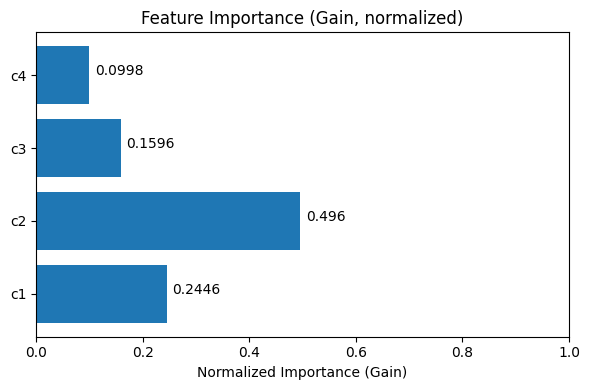

{'c1': 0.2446, 'c2': 0.496, 'c3': 0.1596, 'c4': 0.0998}


In [ ]:
booster = model.get_booster()
scores = booster.get_score(importance_type="gain")

# Normalize to sum to 1
total = sum(scores.values())
normalized = {k: round(v / total, 4) for k, v in scores.items()}

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(list(normalized.keys()), list(normalized.values()))
ax.set_xlim(0, 1)
ax.set_xlabel("Normalized Importance (Gain)")
ax.set_title("Feature Importance (Gain, normalized)")
for i, (k, v) in enumerate(normalized.items()):
    ax.text(v + 0.01, i, str(v))
plt.tight_layout()
plt.show()

print(normalized)

#### User Preferences

Based on the gain-based feature importance, the decision maker weights c2 most heavily (~47% of total gain), followed by c1 (~23%), c3 (~15%) and c4 (~10%).
This suggests the user's decisions are primarily driven by c2 — alternatives with high c2 values are strongly pushed toward the high class regardless of
other criteria.

### Dependencies Between Criteria

The SHAP dependence plot shows SHAP values for c1 colored by c2 value.

At c1=0.5–1.0, high c2 (red) produces higher SHAP values than low c2 (blue), meaning the contribution of c1 is amplified when c2 is also high.
c1 and c2 are not fully independent: high values on both criteria together push more strongly toward the high class than either criterion alone.
This was also visible in the waterfall for alternative 757, where c1=1.0 and c2=0.25 pulled in opposite directions, partially cancelling each other out.

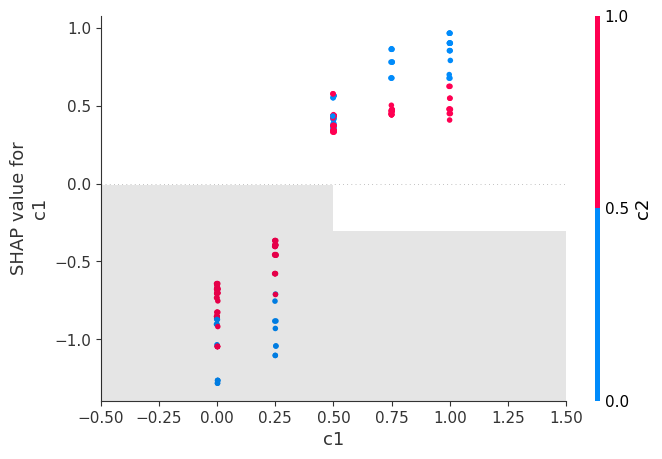

In [34]:

shap.plots.scatter(shap_values[:, "c1", 1], color=shap_values[:, "c2", 1])

### Partial Dependence Plots (PDP)

PDP shows the average predicted probability for each class as a single criterion
varies across its range, with all other criteria held at their mean.
Flat regions indicate indifference — the criterion has no effect in that range.
Steep regions indicate preference thresholds where small changes matter most.

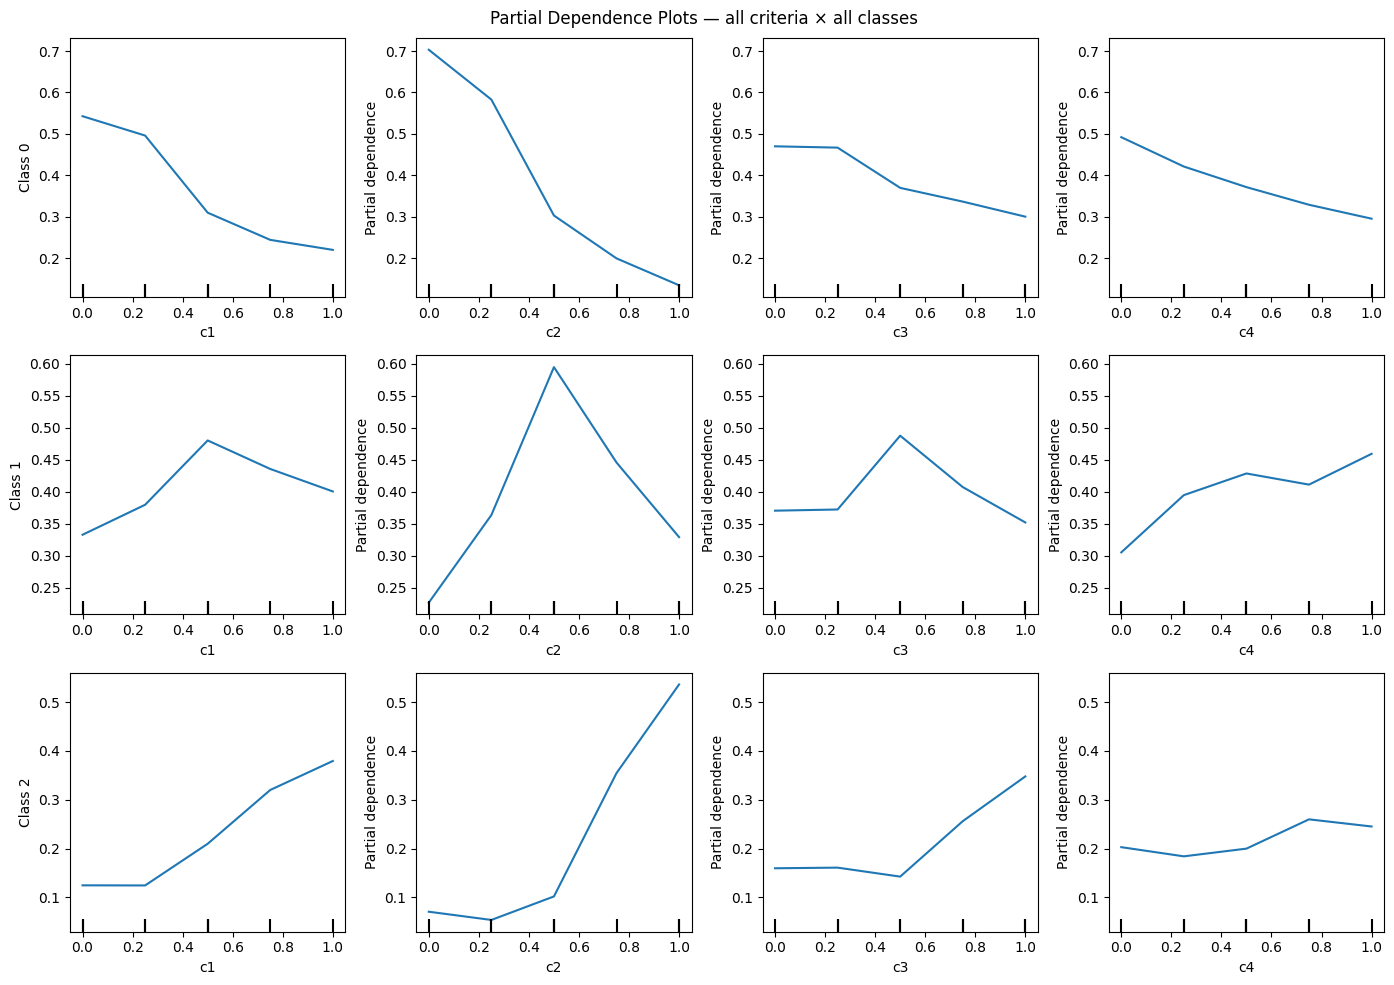

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for cls in range(3):
    PartialDependenceDisplay.from_estimator(
        model, X_train,
        features=[0, 1, 2, 3],
        target=cls,
        ax=axes[cls],
    )
    axes[cls][0].set_ylabel(f"Class {cls}")

plt.suptitle("Partial Dependence Plots — all criteria × all classes")
plt.tight_layout()
plt.show()

## PDP Interpretation

Common behaviour across class 1 PDP plots: all criteria show a non-monotonic shape —
probability rises then falls as the criterion increases. This is expected: monotone_constraints
enforce that higher values push toward higher classes overall, not that each individual
class probability must be monotone. The middle class naturally peaks at intermediate values.

Criterion-wise PDP analysis:

c1: non-monotonic for class 1 (peaks ~0.4 then slightly drops), monotone for classes 0 and 2.
Higher c1 → less class 0, more class 2. 

c2: most influential criterion. Non-monotonic for class 1 — peaks sharply at ~0.5 then drops.
Low c2 → class 0, medium c2 → class 1, high c2 → class 2.

c3: similar non-monotonic pattern for class 1, peaks around 0.5–0.6 then flattens.
Weak but present effect on class 2. Mostly flat for class 0 until ~0.4.

c4: weakest criterion overall. Near-flat curves across all classes, slight non-monotonicity
in class 1. Confirms lowest importance from gain plot.

## Model Interpretation Summary

**Criterion influence:** c2 is the dominant criterion (~47% normalized gain), followed
by c1 (~23%), c3 (~15%), c4 (~10%). No criterion has zero effect but c4 is close
to negligible.

**Nature of criteria:** all 4 criteria are gain-type — higher values consistently
push toward higher classes, confirmed by monotone PDP slopes for classes 0 and 2
and by SHAP showing red (high value) always on the positive side.

**Non-monotonicity:** class 1 probability curves are non-monotonic for all criteria —
they peak at intermediate values then drop. This is expected behavior for the middle
class in a sorting problem, not a violation of preferences.

**Preference thresholds:** PDP plots reveal a sharp threshold on c2 around 0.5 —
below this the model strongly predicts class 0, above it shifts toward class 2.
c1 shows a smoother gradient with no sharp threshold.

**Indifference regions:** c3 and c4 show flat PDP regions especially for class 0,
suggesting the decision maker is largely indifferent to these criteria at low values.

**Dependencies:** SHAP waterfall for alternative 757 shows c1 and c2 pulling in
opposite directions — suggesting these criteria interact. High c1 alone is not
sufficient if c2 is low.